# 07. Transformer Architecture 

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-04-05">5 Apr 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/07_transformer.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
    The following source was consulted in preparing this material:
  </p>
  <ul style="margin-top: 0;">
    <li>
      Zhang, A., Lipton, Z. C., Li, M., &amp; Smola, A. J.
      <a href="https://d2l.ai/">Dive into Deep Learning</a>. Cambridge University Press.
      <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html">Attention Mechanisms and Transformers</a>.
    </li>
  </ul>
</div>

## Attention

The infamous [Transformer](https://en.wikipedia.org/wiki/Transformer_(deep_learning)) architecture, the backbone of large language models like [GPT](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer)<span class="fn"><span class="fn-body">GPT stands for Generative Pretrained Transformer</span></span> did not appear from nowhere. It grew out of the [encoder-decoder](../06_rnn_sequential#encoder-decoder-architecture) view of [sequence modeling](../06_rnn_sequential/#language-modeling). In a [seq2seq](https://en.wikipedia.org/wiki/Seq2seq) model, an encoder reads the source sequence and a decoder produces the target sequence. In the classical recurrent version, both parts are built from [recurrent neural networks](../06_rnn_sequential/#recurrent-neural-networks), so the model depends on the ideas of hidden state, token-by-token processing, and conditional prediction. A compact way to write the basic seq2seq setup is
$$
c = \operatorname{Encoder}(x_1, x_2, \dots, x_T),
\qquad
y_t = \operatorname{Decoder}(y_{<t}, c).
$$
The meaning is simple. The source tokens are $x_1,\dots,x_T$, the encoder turns them into a single context vector $c$, and the decoder predicts the next target token $y_t$ from the earlier target tokens $y_{<t}$ and that same context vector. This makes the model elegant, but it also creates pressure on $c$: one vector must carry whatever information the decoder may need later. That limitation was one of the main motivations for [attention](https://en.wikipedia.org/wiki/Attention_(machine_learning)) in neural machine translation ([Bahdanau et al., 2014](https://arxiv.org/abs/1409.0473)). Before introducing the general attention formula, the next cell makes the explained limitation concrete with a tiny toy example. We will use four source vectors $h_1,\dots,h_4$, first imitate the old seq2seq idea with one fixed context vector, and then build two different step-specific contexts from the same source sequence. The numbers are hard-coded so that the contrast is easy to see.

In [1]:
import torch
import matplotlib.pyplot as plt

tokens = ["the", "cat", "sat", "down"]
decoder_steps = ["step 1", "step 2"]

H = torch.eye(len(tokens))
c_fixed = H[-1]

H, c_fixed

(tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]]),
 tensor([0., 0., 0., 1.]))

In [2]:
# attention weights
A = torch.tensor([
    [0.70, 0.20, 0.10, 0.00],
    [0.10, 0.40, 0.00, 0.50],
])

C = A @ H

C.tolist()

[[0.699999988079071, 0.20000000298023224, 0.10000000149011612, 0.0],
 [0.10000000149011612, 0.4000000059604645, 0.0, 0.5]]

The difference is now visible. The fixed context $c$ stays the same no matter what the decoder is trying to generate, but the two step-specific contexts are different even though they come from the same source sequence. That is the basic intuition behind attention: instead of forcing the decoder to rely on one frozen summary, we let it build the summary it needs at the current step. In its simplest form, the step-specific context is written as
$$
c_t = \sum_{i=1}^{T} \alpha_{t,i} h_i.
$$
Here $h_i$ is the encoder representation at source position $i$, $\alpha_{t,i}$ tells us how much that position matters when predicting the target token at step $t$, and $c_t$ is the weighted sum that the decoder uses at that step. So the old seq2seq model keeps returning to the same $c$, while the attention-based model forms a changing context $c_t$. From a [linear algebra](../../mathematics/02_linear_algebra) point of view this is just a weighted sum of vectors, while from a modeling point of view it is a major change because the decoder can now look back at different parts of the source sequence as needed. The next part of the notebook will make this precise by introducing queries, keys, and values, which are the basic objects used to compute attention matrix.

## Query, Key, and Value

The formula from the previous section says that the decoder no longer uses the same frozen summary at every step. To make that idea precise, we now separate three roles. The current need of the model is represented by a query. The source-side items that can be matched against that need are represented by keys. The actual pieces of information that will be mixed together are represented by values. This is why [attention](https://en.wikipedia.org/wiki/Attention_(machine_learning)) is often explained through the language of a [database](https://en.wikipedia.org/wiki/Database): a query is compared against keys, and the result tells us how strongly to retrieve the corresponding values. In symbols, if the source-side collection is $D = \{(k_1, v_1), \dots, (k_m, v_m)\}$, then attention produces
$$
\operatorname{Attn}(q, D) = \sum_{i=1}^{m} \alpha(q, k_i) v_i.
$$
Here $q$ is the query, $k_i$ is the key for item $i$, $v_i$ is its value, and $\alpha(q, k_i)$ is the weight assigned to that item. So attention does not directly output one source vector. It outputs a weighted combination of values. The next two cells make this concrete with one query and four key-value pairs. The values are chosen to be especially easy to inspect, so the mechanics are visible before we move to the full matrix form.

In [3]:
tokens = ["the", "cat", "sat", "down"]

k = torch.eye(len(tokens))
v = k.clone()
q = torch.tensor([0.0, 0.2, 1.0, 0.8])

scores = q @ k.T
scores

tensor([0.0000, 0.2000, 1.0000, 0.8000])

Because the keys are the standard basis vectors, the [dot product](https://en.wikipedia.org/wiki/Dot_product) between $q$ and each key simply picks out one coordinate of $q$. So the raw scores already tell us how compatible the query is with each source position. Larger scores mean stronger match. To turn these raw scores into usable attention weights, we normalize them with the [softmax function](https://en.wikipedia.org/wiki/Softmax_function). We will study softmax more carefully later; for now we only need one fact: it turns raw scores into nonnegative weights that sum to $1$.

In [4]:
weights = torch.softmax(scores, dim=0)
context = weights @ v

weights, context

(tensor([0.1396, 0.1705, 0.3794, 0.3106]),
 tensor([0.1396, 0.1705, 0.3794, 0.3106]))

The result is especially transparent here because we deliberately set the values equal to the keys. For that reason, the context vector numerically matches the attention weights. That is not a general rule; it is just a clean teaching example. What matters is the pattern. The query places most weight on the third and fourth items, so the resulting context is shaped mostly by those values. This is the basic role of queries, keys, and values in attention. The query says what the model is looking for now, the keys determine how strongly each item matches that need, and the values are the vectors that are actually combined.

We should note one important nuance here. Attention usually runs on batches of sequences, and those sequences often have different lengths. To place them in the same batch, we pad the shorter ones, similar to what we saw in the RNN lecture. As padded positions are not real tokens, attention should not assign weight to them. That is why we need a **masked** version of the softmax function. If only the first $\ell$ positions are valid, then the masked version should normalize over those positions only and force the rest to zero:
$$
\alpha_i = \frac{e^{s_i}}{\sum_{j=1}^{\ell} e^{s_j}} \text{ for } i \leq \ell,
\qquad
\alpha_i = 0 \text{ for } i > \ell.
$$

In [5]:
# 0.0 represents padding here
scores = torch.tensor([
    [2.0, 1.0, 0.0, 0.0],
    [0.3, 1.4, 0.2, 0.0],
])

torch.softmax(scores, dim=-1)

tensor([[0.6103, 0.2245, 0.0826, 0.0826],
        [0.1770, 0.5317, 0.1602, 0.1311]])

Even though the first example should only use its first two positions and the second example should only use its first three, vanilla softmax still spreads some weight onto the padded positions. In a model it would allow meaningless padding tokens to influence the context vector. So we need to hide positions beyond the valid length before softmax is applied. The usual trick is simple: replace masked entries by a very large negative number. After exponentiation inside softmax, those entries contribute essentially zero.

In [6]:
valid_lens = torch.count_nonzero(scores, dim=-1) 
mask = torch.arange(scores.size(-1)) < valid_lens.unsqueeze(1)
masked_scores = scores.masked_fill(~mask, float('-inf')) # ~ is "not" operator

mask, masked_scores

(tensor([[ True,  True, False, False],
         [ True,  True,  True, False]]),
 tensor([[2.0000, 1.0000,   -inf,   -inf],
         [0.3000, 1.4000, 0.2000,   -inf]]))

In [7]:
weights = torch.softmax(masked_scores, dim=-1)
weights

tensor([[0.7311, 0.2689, 0.0000, 0.0000],
        [0.2037, 0.6120, 0.1843, 0.0000]])

Now the padded positions receive zero weight, while the valid positions are renormalized to sum to $1$. This is the form we will use from now on. In later Transformer code, attention scores will usually appear as matrices or batches of matrices rather than small vectors, but the same masking idea still applies.

## Scaled Dot-Product Attention

The previous section explained what queries ($q$), keys ($k$), and values ($v$) are, and it also showed why padded positions must be hidden before softmax. We can now complete the picture by writing the rule that turns a query and a set of keys into attention scores. In modern Transformer models, the standard rule is *scaled dot-product attention* ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)). Simply, the raw compatibility scores are computed with the dot product:
$$
s_i = q^\top k_i.
$$
This is a natural similarity score. If $q$ and $k_i$ point in similar directions, the dot product is large. If they disagree, it is smaller or even negative. To turn these raw scores into attention weights, we apply softmax. However, we do not use $q^\top k_i$ directly. We divide by $\sqrt{d}$, where $d$ is the key dimension:
$$
\alpha_i = \frac{\exp\!\left(q^\top k_i / \sqrt{d}\right)}{\sum_{j=1}^{m} \exp\!\left(q^\top k_j / \sqrt{d}\right)}.
$$
The scaling matters because dot products usually grow in magnitude as the dimension grows. If we fed very large scores directly into softmax, the resulting weights could become too sharp too early. Dividing by $\sqrt{d}$ keeps the scale more stable.

In [8]:
d = torch.tensor(masked_scores.size(-1))
scaled_scores = masked_scores / torch.sqrt(d)
scaled_weights = torch.softmax(scaled_scores, dim=-1)

weights, scaled_weights

(tensor([[0.7311, 0.2689, 0.0000, 0.0000],
         [0.2037, 0.6120, 0.1843, 0.0000]]),
 tensor([[0.6225, 0.3775, 0.0000, 0.0000],
         [0.2714, 0.4704, 0.2582, 0.0000]]))

If the components of $q$ and $k$ are independent with mean $0$ and variance $1$, then the dot product still has mean $0$, but its variance grows with $d_k$. So when $d_k$ becomes large, the raw attention scores tend to spread out more. After softmax, that wider spread often makes the distribution too sharp: one or two positions get almost all the weight, while the others get almost none. That is bad for optimization because the gradients become less informative. This is the motivation given in the original Transformer paper ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)). It should resemble [weight initialization](../04_regul_optim/#weight-initialization) and [batch normalization](../05_cnn_architectures/#batch-normalization).

In [9]:
var = []
scaled_var = []

for d in [4, 16, 64, 256]:
    q = torch.randn(1000, d)
    k = torch.randn(1000, d)

    scores = (q * k).sum(dim=-1)
    scaled_scores = scores / torch.sqrt(torch.tensor(d))

    var.append(scores.var(unbiased=False))
    scaled_var.append(scaled_scores.var(unbiased=False))

var, scaled_var

([tensor(4.0979), tensor(14.8821), tensor(62.1354), tensor(258.6028)],
 [tensor(1.0245), tensor(0.9301), tensor(0.9709), tensor(1.0102)])

We can now write attention in matrix form. Suppose $Q$ is a matrix of queries, $K$ is a matrix of keys, and $V$ is a matrix of values. Then scaled dot-product attention is
$$
\operatorname{Attn}(Q, K, V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V.
$$
The product $QK^\top$ computes many dot products at once, so every query is compared with every key. Softmax turns each row of raw scores into attention weights. Multiplying by $V$ then forms the weighted sums of the values. The next cell uses a tiny batched example so that we can see the weights and resulting context vectors explicitly before moving on to larger Transformer blocks. Below, the tensor `weights` tells us how strongly each query attends to each key, and `attention` (context) is the weighted sum of the values.

In [10]:
def scaled_dot_product_attention(Q, K, V):
    d = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / torch.sqrt(torch.tensor(d))
    weights = torch.softmax(scores, dim=-1)
    attention = weights @ V
    return attention, weights

Q = torch.tensor([
    [[1.0, 0.0], [0.0, 1.0]],
    [[1.0, 1.0], [1.0, 0.0]],
])

K = torch.tensor([
    [[1.0, 0.0], [0.0, 1.0], [1.0, 1.0], [0.0, 0.5]],
    [[1.0, 1.0], [0.0, 1.0], [1.0, 0.0], [5.0, 5.0]],
])

V = torch.tensor([
    [[10.0, 0.0], [0.0, 10.0], [5.0, 5.0], [2.0, 8.0]],
    [[1.0, 1.0], [0.0, 2.0], [2.0, 0.0], [9.0, 9.0]],
])

attention, weights = scaled_dot_product_attention(Q, K, V)

Q.shape, K.shape, V.shape

(torch.Size([2, 2, 2]), torch.Size([2, 4, 2]), torch.Size([2, 4, 2]))

In [11]:
weights, weights.shape

(tensor([[[0.3349, 0.1651, 0.3349, 0.1651],
          [0.1543, 0.3130, 0.3130, 0.2198]],
 
         [[0.0035, 0.0017, 0.0017, 0.9931],
          [0.0515, 0.0254, 0.0515, 0.8716]]]),
 torch.Size([2, 2, 4]))

In [12]:
attention, attention.shape

(tensor([[[5.3534, 4.6466],
          [3.5475, 6.4525]],
 
         [[8.9449, 8.9449],
          [7.9987, 7.9464]]]),
 torch.Size([2, 2, 2]))

## Multi-Head Attention

_Scaled dot-product attention_ gives one set of attention weights and one weighted sum of values. That is already useful, but in language modeling a single attention pattern is often too limited. When predicting the next token, the model may need to track different kinds of information at the same time. One part may need to focus on the most recent word, another on a subject from several positions earlier, and another on the token that should agree in tense, number, or meaning. This is the idea behind *multi-head attention*: instead of computing attention once, we compute it several times in parallel on different learned versions of the same input, then combine the results. A compact way to write this is
$$
\operatorname{MHA}(Q,K,V)=\operatorname{Concat}(\text{head}_1,\dots,\text{head}_h),
\qquad
\text{head}_i=\operatorname{Attn}(Q_i,K_i,V_i).
$$

This says that each head gets its own projected queries, keys, and values, performs attention separately, and produces its own output. We then concatenate the outputs of all heads. So one head gives one way to attend, while multiple heads let the model look at the same sequence in several ways at once.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    For example, in a sentence like <em>The cats on the sofa are sleeping</em>, one head might focus on nearby tokens such as <em>are</em> and <em>sleeping</em>, while another might connect <em>cats</em> with <em>are</em>. In a sequence like <em>I grew up in Azerbaijan, so I speak fluent ...</em>, one head may focus on the most recent phrase, while another attends back to <em>Azerbaijan</em>. We should not think of heads as manually assigned grammar rules, but these examples give the right intuition: different heads can specialize in different useful patterns.
  </p>
</div>


In [13]:
X = torch.tensor([[
    [2.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 2.0, 0.0],
    [0.0, 0.0, 1.0, 1.0],
]])

Q1 = K1 = V1 = X[:, :, :2]
Q2 = K2 = V2 = X[:, :, 2:]

head1, weights1 = scaled_dot_product_attention(Q1, K1, V1)
head2, weights2 = scaled_dot_product_attention(Q2, K2, V2)

weights1[0], weights2[0]

(tensor([[0.7346, 0.1786, 0.0434, 0.0434],
         [0.4022, 0.4022, 0.0978, 0.0978],
         [0.2500, 0.2500, 0.2500, 0.2500],
         [0.2500, 0.2500, 0.2500, 0.2500]]),
 tensor([[0.2500, 0.2500, 0.2500, 0.2500],
         [0.2500, 0.2500, 0.2500, 0.2500],
         [0.0434, 0.0434, 0.7346, 0.1786],
         [0.0978, 0.0978, 0.4022, 0.4022]]))

This example is artificial on purpose. The first head only sees the first two coordinates, and the second head only sees the last two. So the two heads look at different parts of the same token representation. That is why they produce different attention patterns. In a real Transformer, these projections are not chosen by hand like this and are learned during training. But the effect is the same: different heads can focus on different relationships.

In [14]:
multi_head_output = torch.cat([head1, head2], dim=-1)
multi_head_output, multi_head_output.shape

(tensor([[[1.6477, 0.1786, 0.7500, 0.2500],
          [1.2066, 0.4022, 0.7500, 0.2500],
          [0.7500, 0.2500, 1.6477, 0.1786],
          [0.7500, 0.2500, 1.2066, 0.4022]]]),
 torch.Size([1, 4, 4]))

The concatenated output has four features again, because we joined two heads of width 2 each. This is the basic structure of multi-head attention: split the representation into several smaller views, run attention separately, then join the results back together.

## Self-Attention

We can now look at the most important special case of multi-head attention. In *self-attention*, the queries, keys, and values all come from the same sequence. If the input sequence is represented by $X$, then the idea is written compactly as
$$
\operatorname{SelfAttn}(X)=\operatorname{Attn}(X,X,X).
$$
This means that each token forms a query, compares itself with every token in the same sequence, and then builds a new representation as a weighted sum of those token vectors. In language modeling, this is exactly what we want. When processing a token such as *sat*, the model may need to look at nearby words, earlier words, or even the token itself. Self-attention gives every token direct access to the whole sequence in one step.

In [15]:
self_attention, self_weights = scaled_dot_product_attention(X, X, X)
self_weights[0], self_attention[0]

(tensor([[0.6103, 0.2245, 0.0826, 0.0826],
         [0.3655, 0.3655, 0.1345, 0.1345],
         [0.0826, 0.0826, 0.6103, 0.2245],
         [0.1345, 0.1345, 0.3655, 0.3655]]),
 tensor([[1.4451, 0.2245, 0.2478, 0.0826],
         [1.0966, 0.3655, 0.4034, 0.1345],
         [0.2478, 0.0826, 1.4451, 0.2245],
         [0.4034, 0.1345, 1.0966, 0.3655]]))

The attention weights are easiest to read row by row. Each row corresponds to one query token, and each column corresponds to one key token. So row $i$ tells us how the $i$-th token distributes its attention across the full sequence. The output still has the same number of tokens as the input, but now each token representation has been updated using information from the others. This is the key difference from a recurrent model: instead of passing information forward one step at a time, self-attention lets all token-to-token interactions be computed together.

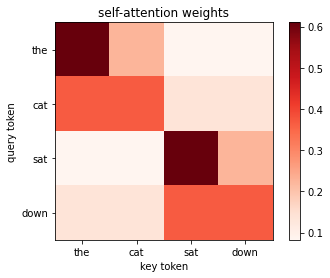

In [16]:
plt.imshow(self_weights[0].detach().numpy(), cmap="Reds")
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("key token")
plt.ylabel("query token")
plt.title("self-attention weights")
plt.colorbar()
plt.show()

This example is still small and artificial, but the structure is already the same as in a Transformer. Each token asks *which other tokens matter for updating my representation?* Some rows may concentrate on nearby tokens, some may spread more broadly, and some may give strong weight to the token itself. Once we combine self-attention with the multi-head idea, the model can learn several such patterns in parallel. One important issue still remains, however: self-attention by itself does not know the order of tokens.

## Positional Encoding

If we shuffle the same token vectors into a different order, self-attention still computes the same kind of matching, as it has no built-in notion of first, second, or last position. That is a serious problem for language, because order changes meaning. The usual fix in the original Transformer paper is simple: before applying attention, add a position-dependent vector to each token embedding. If the token embedding at position $i$ is $x_i$ and the positional vector is $p_i$, then the actual input to the Transformer layer is $z_i = x_i + p_i$. Here, the vector $x_i$ tells the model *what* the token is, and the vector $p_i$ tells it *where* the token is. Adding them keeps the representation size unchanged, which is convenient because attention layers can then use the same dimension throughout the model.

In [32]:
# Sequence: "The cat sat" (3 tokens, 4-dim embeddings)
X = torch.randn(1, 3, 4)

# Shuffled version: "sat The cat"
indices = [2, 0, 1]
X_shuffled = X[:, indices, :]

# Attention
attn_original = scaled_dot_product_attention(X, X, X)
attn_shuffled = scaled_dot_product_attention(X_shuffled, X_shuffled, X_shuffled)

attn_original[0], attn_shuffled[0]

(tensor([[[ 1.7345,  0.1160,  0.0746,  0.9651],
          [ 1.6001, -0.1974,  0.0715,  0.4042],
          [ 0.9139,  0.6760,  0.1562,  1.2032]]]),
 tensor([[[ 0.9139,  0.6760,  0.1562,  1.2032],
          [ 1.7345,  0.1160,  0.0746,  0.9651],
          [ 1.6001, -0.1974,  0.0715,  0.4042]]]))

When the sequence is shuffled, the attention output is shuffled with it. Nothing inside plain self-attention marks one vector as coming from position 1 and another as coming from position 2. So we need to inject position information explicitly. The original Transformer uses a fixed *sinusoidal positional encoding*. For model dimension $d$, the encoding is defined by
$$
p_{i, 2j} = \sin\!\left(\frac{i}{10000^{2j/d}}\right), \qquad
p_{i, 2j+1} = \cos\!\left(\frac{i}{10000^{2j/d}}\right).
$$
Here $i$ is the token position and $j$ selects the coordinate pair inside the positional vector. The even coordinates use sine and the odd coordinates use cosine. Different coordinates change at different speeds. Low-frequency coordinates vary slowly across positions, while high-frequency coordinates vary more quickly. This gives each position a distinct pattern while keeping the encoding dimension the same as the token embedding dimension.

In [33]:
def positional_encoding(num_positions, d_model):
    positions = torch.arange(num_positions).unsqueeze(1)
    div_term = torch.pow(10000, torch.arange(0, d_model, 2) / d_model)
    P = torch.zeros(num_positions, d_model)
    P[:, 0::2] = torch.sin(positions / div_term)
    P[:, 1::2] = torch.cos(positions / div_term)
    return P

P = positional_encoding(20, 16)
P[:4, :8]

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.3110,  0.9504,  0.0998,  0.9950,  0.0316,  0.9995],
        [ 0.9093, -0.4161,  0.5911,  0.8066,  0.1987,  0.9801,  0.0632,  0.9980],
        [ 0.1411, -0.9900,  0.8126,  0.5828,  0.2955,  0.9553,  0.0947,  0.9955]])

The next cell visualizes the positional encoding. The line plot helps us see that different coordinates oscillate at different rates. The heatmap then shows the full pattern across positions. Both views matter. The line plot makes the sinusoidal definition concrete, and the heatmap makes it clear that each position receives a distinct vector.

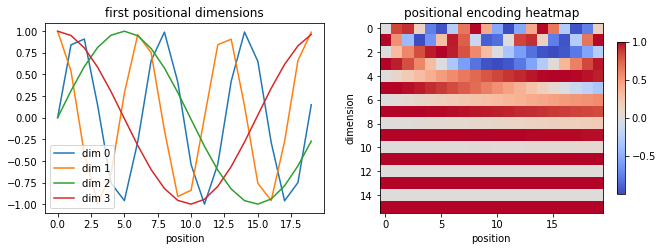

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for j in range(4):
    axes[0].plot(P[:, j], label=f"dim {j}")
axes[0].set_xlabel("position")
axes[0].set_title("first positional dimensions")
axes[0].legend()

im = axes[1].imshow(P.T, cmap="coolwarm", aspect="auto")
axes[1].set_xlabel("position")
axes[1].set_ylabel("dimension")
axes[1].set_title("positional encoding heatmap")
fig.colorbar(im, ax=axes[1], shrink=0.8)
plt.show()

We can now add positional encodings to token embeddings exactly as in $z_i = x_i + p_i$. The next cell uses a very simple embedding matrix so that the effect is easy to read numerically. The token information is still there, but now each position receives an extra offset that depends only on where the token appears in the sequence.

In [36]:
X_tokens = torch.tensor([
    [1.0, 0.5, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0],
    [0.8, 0.1, 0.0, 0.0, 0.3, 0.0, 0.0, 0.0],
    [0.9, 0.2, 0.0, 0.0, 0.4, 0.0, 0.0, 0.0],
    [0.7, 0.3, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0],
])

Z = X_tokens + positional_encoding(X_tokens.size(0), X_tokens.size(1))
Z

tensor([[ 1.0000e+00,  1.5000e+00,  0.0000e+00,  1.0000e+00,  2.0000e-01,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 1.6415e+00,  6.4030e-01,  9.9833e-02,  9.9500e-01,  3.1000e-01,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 1.8093e+00, -2.1615e-01,  1.9867e-01,  9.8007e-01,  4.2000e-01,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 8.4112e-01, -6.8999e-01,  2.9552e-01,  9.5534e-01,  1.3000e-01,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])

After this addition, two identical token embeddings placed at different positions would no longer look identical to the model. That is exactly the point. Self-attention is still responsible for deciding *which* tokens should interact, but positional encoding makes sure the model can also tell *where* those tokens are. At this stage we have the main attention ingredients in place: queries, keys, values, scaled dot-product attention, multi-head attention, self-attention, and positional encoding. The next step is to assemble these ingredients into the actual Transformer block. We will start with the two remaining components that sit around attention in the architecture: the positionwise feed-forward network and the residual-plus-normalization step.